## CONTENTS

- Introduction
- Methodology
- Dataset
- Dataset Overview
- Exploratory Data Analysis
- Data Preparation
- Sales Analysis
- Customer Retention Cohort Analysis
- RFM Analysis
- K-Means Clustering
- Business Insights
- Executive Dashboard
- Key findings
- Limitations
- Conclusion
- Business Impact
- Next steps

## INTRODUCTION

The objective of this project is to support business decision-making by identifying customer segments with different purchasing behaviors and proposing marketing strategies tailored to each group. Customer segmentation is one of the most valuable applications of data analytics in retail, as it enables businesses to better understand customer behavior, improve customer retention, optimize marketing campaigns, and allocate resources more effectively.

For this purpose, we will analyze a retail transaction dataset containing over 525,000 sales records collected between December 2009 and December 2010. The analysis begins with an exploratory examination of the dataset to assess its structure, identify data quality issues, and understand the characteristics of the transactions. A comprehensive data preparation process is then carried out to remove inconsistent records and ensure the reliability of the subsequent analyses.

After cleaning the data, sales trends and customer activity are explored to identify temporal patterns and seasonality. The study then focuses on RFM (Recency, Frequency, Monetary) analysis, a widely used methodology for evaluating customer purchasing behavior. Based on these metrics, customers are first segmented using predefined business rules and later grouped automatically through the K-Means clustering algorithm.

Finally, the results are interpreted from a business perspective, highlighting the characteristics of each customer segment and proposing actionable recommendations to improve customer retention, increase customer lifetime value, and support data-driven marketing decisions.

The dataset contains the following variables:

| Variable | Description |
|----------|-------------|
| **InvoiceNo** | Unique invoice number. Cancellations begin with the letter **"C"**. |
| **StockCode** | Unique product identifier. |
| **Description** | Product description. |
| **Quantity** | Quantity of items purchased in each transaction. |
| **InvoiceDate** | Date and time of the transaction. |
| **Price** | Unit price (£). |
| **CustomerID** | Unique customer identifier. |
| **Country** | Country where the customer resides. |

For greater clarity, we will rename the **Price** column to **UnitPrice**.

In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

RANDOM_STATE = 42

sales_df = pd.read_excel("../data/raw.xlsx")

sales_df = sales_df.rename(columns={"Price": "UnitPrice"})

## METHODOLOGY

This project follows the CRISP-DM methodology. The process begins with understanding the business objective and the dataset, followed by exploratory data analysis and data preparation. Once the data is cleaned, sales patterns are analyzed, customers are segmented using RFM analysis and K-Means clustering, and the results are translated into actionable business recommendations.

```mermaid
flowchart TD
    A[Business Understanding] --> B[Data Understanding]
    B --> C[Exploratory Data Analysis]
    C --> D[Data Preparation]
    D --> E[Sales Analysis]
    E --> F[RFM Analysis]
    F --> G[K-Means Clustering]
    G --> H[Business Insights]
    H --> I[Executive Dashboard]
```

## DATASET

Source: https://archive.ics.uci.edu/dataset/502/online+retail+ii

Number of rows: 525461

Number of variables: 8

Time period: December 1, 2009, to December 9, 2010

Business problem: The company wants to better understand its customers' purchasing behavior in order to identify distinct customer segments. By classifying customers according to their recency, purchase frequency, and monetary value, the business aims to design targeted marketing campaigns, improve customer retention, increase customer lifetime value, and optimize the allocation of marketing resources.

## DATASET OVERVIEW

As a first step, we explore the dataset by inspecting its shape and displaying the first five rows to gain a better understanding of its structure.

In [2]:
print(sales_df.shape) # 525461 filas, 8 columnas
sales_df.head()

(525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


The dataset contains a total of 525,461 transaction records. Below is a summary of its variables.

In [7]:
summary = pd.DataFrame({
    "n_unique": sales_df.nunique(),
    "missing": sales_df.isna().sum(),
    "missing_pct": (sales_df.isna().mean() * 100).round(2)
})

summary

,n_unique,missing,missing_pct
Invoice,28816,0,0.00
StockCode,4632,0,0.00
Description,4681,2928,0.56
Quantity,825,0,0.00
InvoiceDate,25296,0,0.00
UnitPrice,1606,0,0.00
Customer ID,4383,107927,20.54
Country,40,0,0.00


At first glance, several conclusions can be drawn from the qualitative variables:

- The dataset contains 525,461 transaction records distributed across 28,816 invoices, with an average of 18.23 product lines per invoice.
  
- There are 4,632 distinct stock codes, representing the different products identified in the dataset.

- The Description variable contains 4,681 distinct values, exceeding the number of stock codes. This suggests that some stock codes are associated with multiple descriptions, either because the same product has been named differently or because product descriptions have changed over time. This will be investigated further. In addition, 2,328 records have missing descriptions.

- The dataset includes 4,383 distinct customers, who will be the focus of the customer segmentation analysis. However, 107,927 records (approximately 20.5% of the dataset) have missing customer identifiers, which represents a relatively high proportion.

- Finally, transactions were recorded in 40 different countries. The geographical distribution of sales will be analyzed in the following section.

## EXPLORATORY DATA ANALYSIS

Having completed the dataset overview, we now proceed to the exploratory analysis of the variables.

In [8]:
sales_df["Country"].value_counts(normalize=True).mul(100).round(2)[:20]

Country
United Kingdom          92.46
EIRE                     1.84
Germany                  1.55
France                   1.10
Netherlands              0.53
Spain                    0.24
Switzerland              0.23
Portugal                 0.21
Belgium                  0.20
Channel Islands          0.17
Sweden                   0.17
Italy                    0.14
Australia                0.12
Cyprus                   0.11
Austria                  0.10
Greece                   0.10
United Arab Emirates     0.08
Denmark                  0.08
Norway                   0.07
Finland                  0.07
Name: proportion, dtype: float64

<br>
We observe that the vast majority of transactions took place in the United Kingdom, accounting for 92.46% of the dataset. EIRE (Ireland), Germany, and France rank next in terms of the number of transactions.
<br><br>

Regarding the quantitative and date-related variables, no missing values were found. We will now analyze these variables in greater detail.
<br><br>

In [9]:
# Descripción de variables cuantitativas y relativas a fechas en busca de anomalías

sales_df[["Quantity", "UnitPrice", "InvoiceDate"]].describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,525461.0,10.337667,-9600.0,1.0,3.0,10.0,19152.0,107.42411
UnitPrice,525461.0,4.688834,-53594.36,1.25,2.1,4.21,25111.09,146.126914
InvoiceDate,525461,2010-06-28 11:37:36.845017856,2009-12-01 07:45:00,2010-03-21 12:20:00,2010-07-06 09:51:00,2010-10-15 12:45:00,2010-12-09 20:01:00,NaN


The transactions in the dataset span the period from December 1, 2009, to December 9, 2010.

The average quantity per transaction is slightly above 10 units, while the standard deviation reaches 107. Since the third quartile is equal to 10, this unusually high standard deviation suggests the presence of a small number of transactions involving exceptionally large quantities. This is confirmed by the maximum value of 19,152 units. In addition, the minimum quantity is −9,600 units, indicating the existence of extreme negative transactions that also contribute to the high variability of this variable.

A similar pattern can be observed for the UnitPrice variable. Although the average unit price is only £4.69, the standard deviation is £146.13, indicating the presence of a few transactions with exceptionally high prices. This is reflected in the maximum unit price of £25,111.09. Furthermore, the minimum value is −£53,594.36, revealing the presence of extreme negative price adjustments that further increase the variability of the data.

Finally, both the Quantity and UnitPrice variables contain negative values. Negative quantities are likely associated with product returns or order cancellations, whereas negative unit prices appear to correspond to accounting adjustments. These records will be examined in more detail during the data cleaning process.

## DATA PREPARATION

Before proceeding with the analysis, we perform a data cleaning process to ensure data quality and integrity, thereby improving the reliability of the results.

As a first step in the data cleaning process, we investigate the anomalies identified during the exploratory data analysis. In particular, both the Quantity and UnitPrice variables contain negative values, which will be analyzed in more detail.

### Negative price and quantity

In [10]:
sales_df[sales_df["UnitPrice"] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


<br>
Inspection of the records with negative UnitPrice values reveal that they correspond to accounting adjustments related to bad debt. As these entries do not represent actual customer purchases, they are not relevant to the customer segmentation analysis and will therefore be removed from the dataset.

In [11]:
sales_df[(sales_df["Quantity"] < 0)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom
525235,538162,46000M,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom


<br>Most records with negative Quantity values appear to correspond to cancelled orders, as their invoice numbers start with the prefix "C". We will now investigate whether any negative-quantity transactions do not follow this pattern.

In [12]:
sales_df[(sales_df["Quantity"] < 0) & (~sales_df["Invoice"].str.startswith("C", na=False))] 

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
524458,538092,37467,NaN,-177,2010-12-09 14:49:00,0.0,NaN,United Kingdom
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.0,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.0,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.0,NaN,United Kingdom


<br>Let's analyze these orders in depth, looking at the values of the Customer ID, UnitPrice, and Description variables.

In [13]:
Q_negative_no_cancelled_df = sales_df[(sales_df["Quantity"] < 0) & (~sales_df["Invoice"].str.startswith("C", na=False))]

print("Customer ID analysis:\n")
print(Q_negative_no_cancelled_df["Customer ID"].value_counts(dropna=False))
print("")
print("UnitPrice analysis:\n")
print(Q_negative_no_cancelled_df["UnitPrice"].value_counts(dropna=False))
print("")
print("Description analysis:\n")
print(Q_negative_no_cancelled_df["Description"].value_counts(dropna=False)[:20])

Customer ID analysis:

Customer ID
NaN    2121
Name: count, dtype: int64

UnitPrice analysis:

UnitPrice
0.0    2121
Name: count, dtype: int64

Description analysis:

Description
NaN                                  1827
?                                      42
damages                                39
damaged                                36
missing                                24
dotcom                                  6
given away                              6
checked                                 5
smashed                                 5
ebay sales                              4
Damages                                 4
MIA                                     4
crushed                                 4
check                                   3
counted                                 3
No Stock                                3
Damaged                                 3
Dotcom                                  2
Donated to The Food Chain charity       2
broken zips            

<br>After examining these transactions, we found that all of them have missing values in the Customer ID column and a UnitPrice of zero. Furthermore, inspection of the product descriptions revealed that many records contain missing descriptions, while others include terms such as "damaged" or "missing". This suggests that these entries correspond to lost or damaged items rather than actual customer purchases. A small number of records also refer to donated products.

Since these records represent failed transactions, donations, or internal inventory adjustments rather than genuine customer purchases, they are not relevant to the customer segmentation task and will therefore be removed from the dataset.

After investigating records with negative values in the Quantity and UnitPrice columns, we now examine whether any transactions contain a value of exactly zero in either field.

### Price and quantity equals to 0

In [14]:
sales_df[sales_df["Quantity"] == 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country


<br>No transactions have a Quantity equal to zero. However, we previously found that some records with negative quantities also had a UnitPrice of zero. We will now investigate whether transactions with positive quantities exhibit the same pattern.

In [15]:
sales_df[(sales_df["UnitPrice"] == 0) & (sales_df["Quantity"] > 0)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
5904,489861,DOT,DOTCOM POSTAGE,1,2009-12-02 14:50:00,0.0,NaN,United Kingdom
6378,489882,35751C,NaN,12,2009-12-02 16:22:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
524728,538142,84247C,NaN,1,2010-12-09 15:58:00,0.0,NaN,United Kingdom
524729,538144,90042B,NaN,1,2010-12-09 15:58:00,0.0,NaN,United Kingdom
524730,538141,22218,NaN,2,2010-12-09 15:58:00,0.0,NaN,United Kingdom
524731,538143,84534B,NaN,1,2010-12-09 15:58:00,0.0,NaN,United Kingdom


<br>It's moment to take a closer look at these 1,566 orders.

In [16]:
price_0_df = sales_df[(sales_df["UnitPrice"] == 0) & (sales_df["Quantity"] > 0)]

print("Análisis de clientes")
print(price_0_df["Customer ID"].value_counts(dropna=False))

print("")
print("Análisis de descripción")
print(price_0_df["Description"].value_counts(dropna=False))

Análisis de clientes
Customer ID
NaN        1535
12647.0       5
13047.0       3
14108.0       2
17231.0       1
13554.0       1
14646.0       1
17667.0       1
17450.0       1
15658.0       1
12471.0       1
14025.0       1
13089.0       1
14045.0       1
12748.0       1
12623.0       1
16126.0       1
14827.0       1
14103.0       1
16858.0       1
12417.0       1
14258.0       1
18071.0       1
15070.0       1
12820.0       1
Name: count, dtype: int64

Análisis de descripción
Description
NaN                                 1101
OWL DOORSTOP                           8
PICNIC BASKET WICKER LARGE             7
POLYESTER FILLER PAD 45x45cm           7
HEART OF WICKER SMALL                  6
                                    ... 
FAIRY CAKES NOTEBOOK A7 SIZE           1
WOODLAND PARTY BAG + STICKER SET       1
12 COLOURED PARTY BALLOONS             1
FEATHER PEN,HOT PINK                   1
PACK OF 6 BIRDY GIFT TAGS              1
Name: count, Length: 270, dtype: int64


<br>We observe that the vast majority of these transactions have missing Customer ID values. This suggests that they may correspond to erroneous records or internal inventory adjustments, such as lost or defective items removed from stock. The remaining 31 transactions will now be examined individually.

In [17]:
print(sales_df[(sales_df["UnitPrice"] == 0) & (sales_df["Customer ID"].notna())].shape)
sales_df[(sales_df["UnitPrice"] == 0) & (sales_df["Customer ID"].notna())]

(31, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.0,15070.0,United Kingdom
40101,492760,21143,ANTIQUE GLASS HEART DECORATION,12,2009-12-18 14:22:00,0.0,18071.0,United Kingdom
47126,493761,79320,FLAMINGO LIGHTS,24,2010-01-06 14:54:00,0.0,14258.0,United Kingdom
48342,493899,22355,"CHARLOTTE BAG , SUKI DESIGN",10,2010-01-08 10:43:00,0.0,12417.0,Belgium
57619,494607,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-15 12:43:00,0.0,16858.0,United Kingdom


<br>The remaining 31 transactions with a valid Customer ID appear to be legitimate in most cases, although a few are explicitly labeled as "test product". The remaining records are likely associated with promotional items or free gifts, as they have a UnitPrice of zero despite representing otherwise valid transactions.

Since the objective of this project is to classify customers based on their purchasing behavior and total spending, these records do not contribute meaningful information to the analysis. Therefore, they will be removed from the dataset together with the records identified in the previous sections.

In [18]:
sales_df = sales_df[
    (sales_df["Quantity"] > 0) &
    (sales_df["UnitPrice"] > 0)
]

<br>Here's how the data has changed following this latest update.

In [19]:
summary = pd.DataFrame({
    "n_unique": sales_df.nunique(),
    "missing": sales_df.isna().sum(),
    "missing_pct": (sales_df.isna().mean() * 100).round(2)
})

summary

,n_unique,missing,missing_pct
Invoice,20952,0,0.00
StockCode,4251,0,0.00
Description,4534,0,0.00
Quantity,406,0,0.00
InvoiceDate,19468,0,0.00
UnitPrice,1345,0,0.00
Customer ID,4312,103902,20.31
Country,40,0,0.00


In [20]:
sales_df[["Quantity", "UnitPrice", "InvoiceDate"]].describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,511566.0,11.40015,1.0,1.0,3.0,10.0,19152.0,86.761177
UnitPrice,511566.0,4.252563,0.001,1.25,2.1,4.21,25111.09,63.664629
InvoiceDate,511566,2010-06-28 22:20:30.395491584,2009-12-01 07:45:00,2010-03-21 15:22:00,2010-07-07 09:41:00,2010-10-15 15:06:00,2010-12-09 20:01:00,NaN


After the data cleaning process, the dataset size decreased from 525,461 to 511,566 rows, resulting in the removal of approximately 2.6% of the original records.

After removing records with non-positive Quantity and UnitPrice values, the standard deviation of both variables decreased substantially. We also found that the gap between the number of distinct StockCode and Description values increased. This discrepancy will be investigated in the next section.

### Codes with multiple descriptions

Once anomalies related with quantity or unit price has been studies, we examine stock codes associated with multiple descriptions to determine whether these discrepancies are the result of data entry errors.

In [21]:
stock_desc = (
    sales_df.groupby("StockCode")["Description"]
    .nunique()
    .sort_values(ascending=False)
)

multiple_desc = stock_desc[stock_desc > 1]
len(multiple_desc)

449

<br>We have a total of 449 codes with duplicate descriptions. Let's look at 10 of them.

In [22]:
for code in multiple_desc[:10].keys():
    print(sales_df[sales_df["StockCode"] == code]["Description"].value_counts(dropna=False))
    print()

Description
PARTY PIZZA DISH GREEN RETROSPOT      19
PARTY PIZZA DISH GREEN WHITE SPOT     15
PARTY PIZZA DISH GREEN POLKADOT       11
PARTY PIZZA DISH GREEN+WHITE SPOT      1
Name: count, dtype: int64

Description
DOOR MAT UNION JACK GUNS AND ROSES     231
DOORMAT UNION JACK GUNS AND ROSES      152
UNION JACK GUNS & ROSES  DOORMAT       103
  DOORMAT UNION JACK GUNS AND ROSES     62
Name: count, dtype: int64

Description
LUNCH BAG PINK RETROSPOT    839
LUNCH BAG PINK POLKADOT     220
LUNCHBAG PINK RETROSPOT      14
LUNCH BAG PINK POLKADOTS      1
Name: count, dtype: int64

Description
DOOR MAT RED SPOT          413
DOORMAT RED RETROSPOT      241
RED SPOTTY COIR DOORMAT    209
DOORMAT RED SPOT           207
Name: count, dtype: int64

Description
PARTY PIZZA DISH PINK RETROSPOT      24
PARTY PIZZA DISH PINK WHITE SPOT     19
PARTY PIZZA DISH PINK POLKADOT       14
PARTY PIZZA DISH PINK+WHITE SPOT      2
Name: count, dtype: int64

Description
PARTY PIZZA DISH BLUE RETROSPOT      28
PARTY

The different descriptions associated with the same StockCode appear to result mainly from naming convention changes, typographical inconsistencies, or product catalog updates. Since these variations do not indicate different products, no changes will be applied to either variable.

## SALES ANALYSIS

The next step will be to investigate transactions with missing customer identifiers to better understand their nature and determine whether they should be included in the subsequent analyses.

In [23]:
sales_no_client = sales_df[sales_df["Customer ID"].isna()]
sales_no_client.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom
1059,489548,22131,FOOD CONTAINER SET 3 LOVE HEART,2,2009-12-01 12:32:00,1.95,NaN,United Kingdom
1060,489548,22079,RIBBON REEL HEARTS DESIGN,10,2009-12-01 12:32:00,1.65,NaN,United Kingdom
1061,489548,22138,BAKING SET 9 PIECE RETROSPOT,3,2009-12-01 12:32:00,4.95,NaN,United Kingdom
1062,489548,22147,FELTCRAFT BUTTERFLY HEARTS,2,2009-12-01 12:32:00,1.45,NaN,United Kingdom


<br>These transactions appear to represent legitimate sales. One possible explanation is that they correspond to in-store purchases or online orders placed without customer identification. Consequently, they will be included in the sales analysis but excluded from the customer segmentation analysis, since they cannot be linked to an individual customer.

This section examines the evolution of both sales and the number of active customers over the period covered by the dataset.

As a first step, we create a new variable representing the total value of each transaction by multiplying the quantity of items purchased by their unit price.

In [24]:
sales_df["TotalPrice"] = (
    sales_df["Quantity"] * sales_df["UnitPrice"]
)

<br>Next, we aggregate sales on a monthly basis and calculate the number of active customers, defined as customers who made at least one purchase during each month.

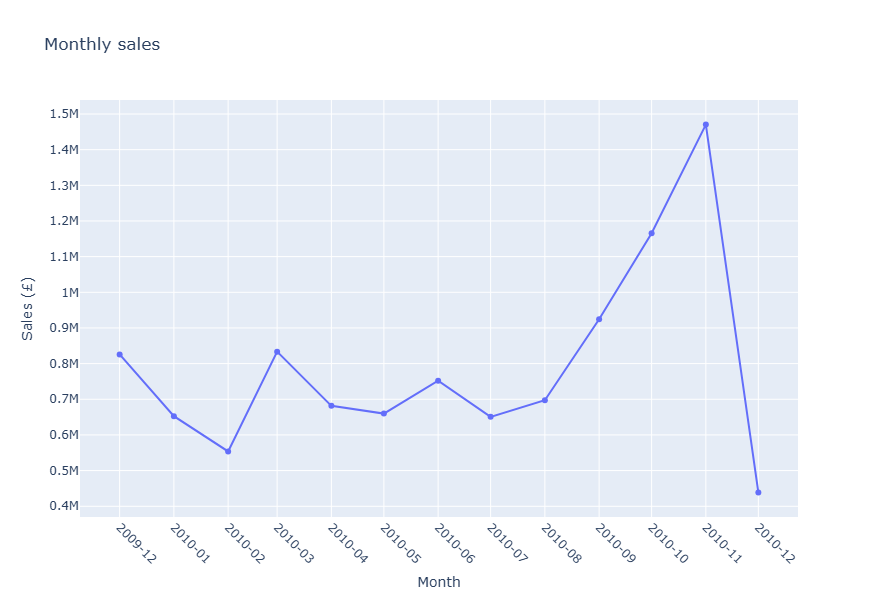

In [25]:
monthly_sales = (
    sales_df
    .groupby(
        sales_df["InvoiceDate"].dt.to_period("M")
    )["TotalPrice"]
    .sum()
    .reset_index(name="sales")
)

monthly_sales["InvoiceDate"] = (
    monthly_sales["InvoiceDate"]
    .dt.to_timestamp()
)

fig = px.line(
    monthly_sales,
    x="InvoiceDate",
    y="sales",
    markers=True,
    title="Monthly sales",
    height=700
)

fig.update_xaxes(
    tickmode="array",
    tickvals=monthly_sales["InvoiceDate"],
    tickformat="%Y-%m",
    tickangle=45
)

fig.update_yaxes(
    dtick=100000,     
    showgrid=True
)

# Mejorar la interacción
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Sales (£)",
    hovermode="x unified",
    height=600
)

fig.show()

Considering that the dataset only includes transactions up to December 9, 2010, whereas December 2009 is fully represented, sales exhibit a clear upward trend throughout 2010, particularly during the last quarter of the year. A sharp increase in sales can be observed between September and November, most likely driven by the Christmas shopping season.

Let's observe the total revenue per weekday.

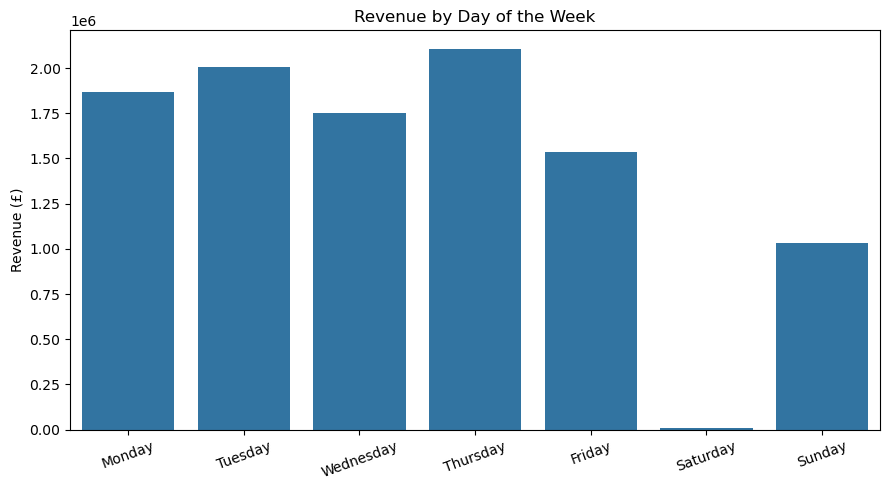

In [26]:
# Crear columna con el día de la semana
sales_df["Weekday"] = sales_df["InvoiceDate"].dt.day_name()

# Orden correcto de los días
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# Agrupar ventas
weekday_sales = (
    sales_df
    .groupby("Weekday")["TotalPrice"]
    .sum()
    .reindex(weekday_order)
    .reset_index()
)

# Gráfico
plt.figure(figsize=(9,5))

sns.barplot(
    data=weekday_sales,
    x="Weekday",
    y="TotalPrice"
)

plt.title("Revenue by Day of the Week")
plt.xlabel("")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

Sales peak on Tuesdays and Thursdays, with total revenue exceeding £2 million on each of these days over the analyzed period. In contrast, Saturday sales are almost nonexistent, suggesting that the store is likely closed on that day. Sunday sales are also considerably lower than on the rest of the week, indicating reduced business activity during the weekend.


Once done the sales analysis per time unit, we are going to see the number of active clients per month.

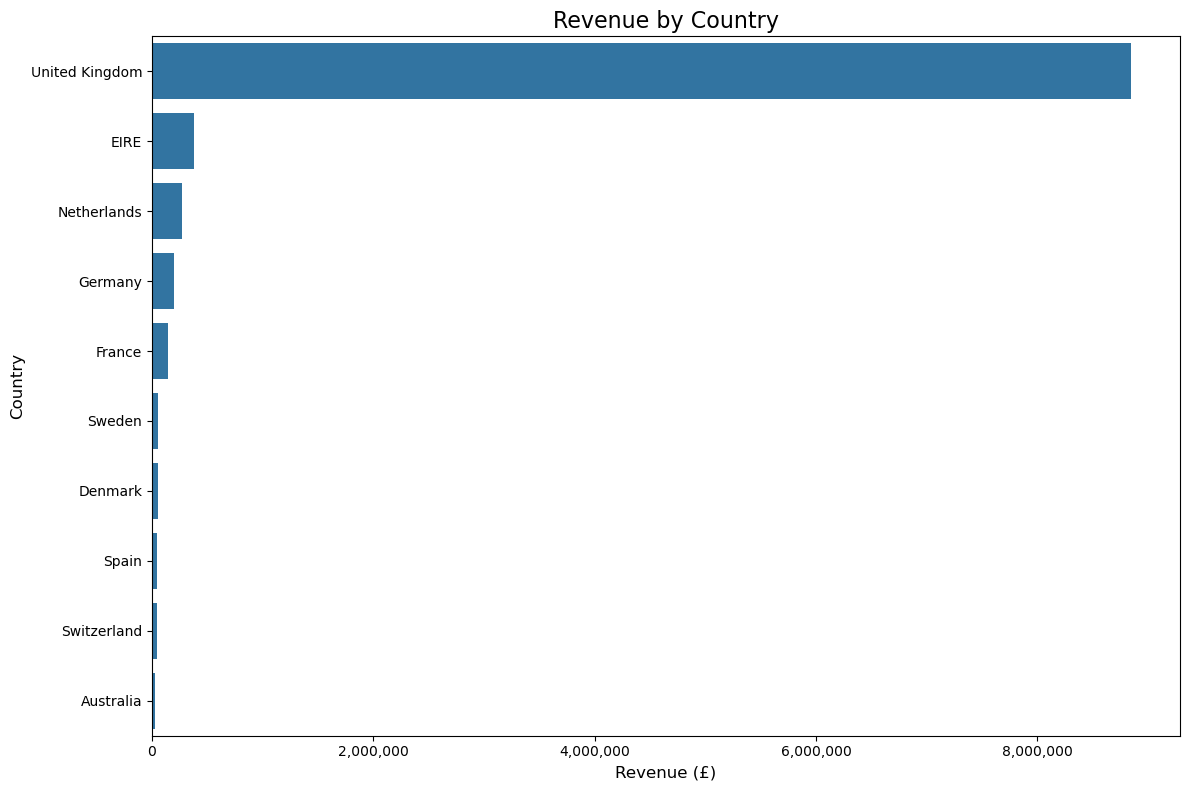

In [27]:
from matplotlib.ticker import StrMethodFormatter

# Revenue by country
country_revenue = (
    sales_df
    .groupby("Country", as_index=False)["TotalPrice"]
    .sum()
    .sort_values("TotalPrice", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=country_revenue,
    y="Country",
    x="TotalPrice"
)

plt.title("Revenue by Country", fontsize=16)
plt.xlabel("Revenue (£)", fontsize=12)
plt.ylabel("Country", fontsize=12)

# Mostrar números completos (sin notación científica)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

The United Kingdom clearly dominates the market, accounting for the vast majority of total revenue with more than £8 million in sales. By comparison, none of the other countries individually generates more than £1 million in revenue.

We now turn our attention to the evolution of the number of active customers on a monthly basis.

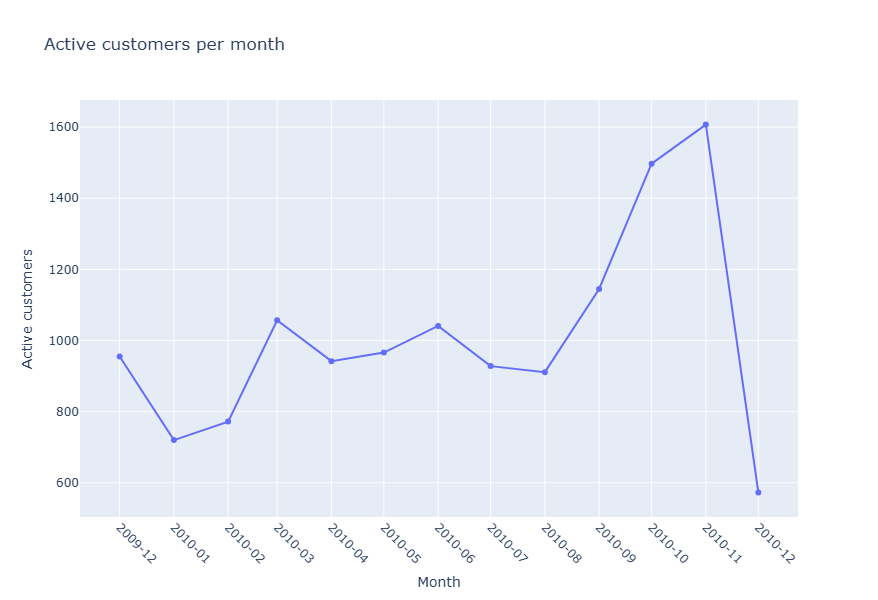

In [28]:
monthly_active_customers = (
    sales_df[sales_df["Customer ID"].notna()]
    .groupby(
        sales_df["InvoiceDate"].dt.to_period("M")
    )["Customer ID"]
    .nunique()
    .reset_index(name="active_customers")
)

monthly_active_customers["InvoiceDate"] = (
    monthly_active_customers["InvoiceDate"]
    .dt.to_timestamp()
)

fig = px.line(
    monthly_active_customers,
    x="InvoiceDate",
    y="active_customers",
    markers=True,
    title="Active customers per month"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Active customers",
    hovermode="x unified",
    height=600
)

fig.update_xaxes(
    tickmode="array",
    tickvals=monthly_active_customers["InvoiceDate"],
    tickformat="%Y-%m",
    tickangle=45
)

fig.show()

The number of active customers follows a similar trend, increasing progressively during 2010 and reaching its highest levels in the final months of the year. As with the sales figures, the December 2010 value should be interpreted with caution, since the dataset only includes transactions up to December 9.

## RFM ANALYSIS

Next, we perform an RFM analysis to segment customers according to their purchasing behavior. The first step is to construct the RFM table, which includes three metrics: Recency, defined as the number of days since the customer's most recent purchase (calculated relative to the day following the last date in the dataset); Frequency, representing the total number of purchases made by the customer; and Monetary, representing the total amount spent during the period analyzed.

### Preparing the Data for RFM Analysis

In [29]:
snapshot_date = sales_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    sales_df
    .groupby("Customer ID")
    .agg(
        Recency=("InvoiceDate",
                 lambda x: (snapshot_date - x.max()).days),
        Frequency=("Invoice", "nunique"),
        Monetary=("TotalPrice", "sum")
    )
)

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


<br>Now let's analyze the distribution of the variables.

In [30]:
rfm.describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2048.238236
std,96.860633,8.170213,8914.481280
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.987500
50%,53.000000,2.000000,706.020000
75%,136.000000,5.000000,1723.142500
max,374.000000,205.000000,349164.350000


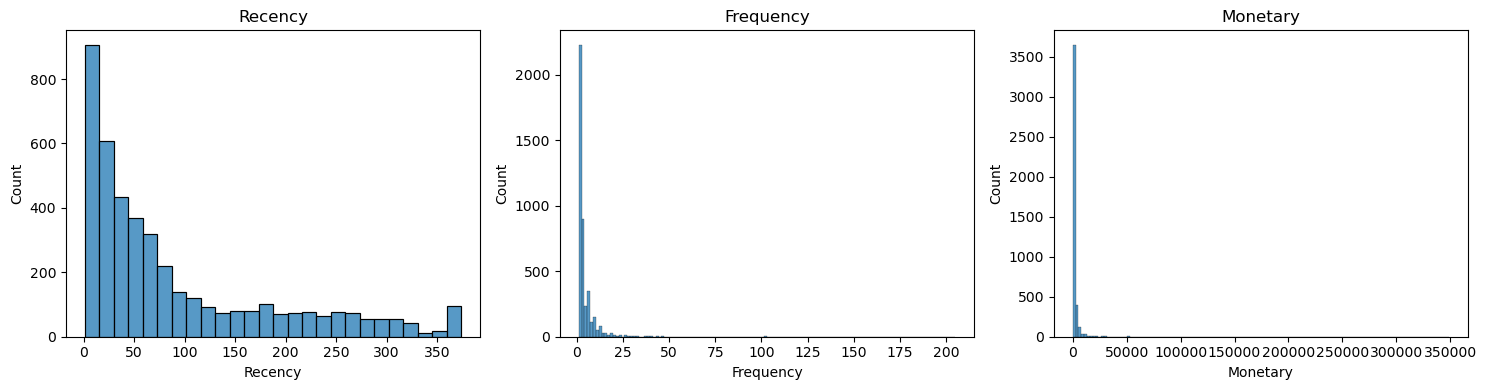

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(rfm["Recency"], ax=axes[0])
axes[0].set_title("Recency")

sns.histplot(rfm["Frequency"], ax=axes[1])
axes[1].set_title("Frequency")

sns.histplot(rfm["Monetary"], ax=axes[2])
axes[2].set_title("Monetary")

plt.tight_layout()

<br>Overall, the RFM metrics are concentrated around relatively low values. Most customers placed only a few orders (median of 2 purchases) and spent a moderate amount (median of £706). The median Recency is 53 days, indicating that half of the customers made a purchase within the last two months of the study period, although a considerable number of customers had been inactive for much longer.

Now let's convert the variables into scores using 5 groups, where higher values are better for the business.

In [32]:
# The fewer days that have passed since the last purchase, the higher the Recency score will be
rfm["R"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5,4,3,2,1]
)

rfm["F"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1,2,3,4,5]
)

rfm["M"] = pd.qcut(
    rfm["Monetary"],
    q=5,
    labels=[1,2,3,4,5]
)

rfm["RFM_Score"] = (
    rfm["R"].astype(str)
    + rfm["F"].astype(str)
    + rfm["M"].astype(str)
)

### RFM Segmentation

<br>Next, we segment customers based on their RFM score

In [33]:
def segment(row):
    if row["R"] >= 4 and row["F"] >= 4 and row["M"] >= 4:
        return "Champions"

    if row["R"] >= 3 and row["F"] >= 3:
        return "Loyal"

    if row["R"] >= 4 and row["F"] <= 2:
        return "New"

    if row["R"] <= 2 and row["F"] >= 4:
        return "At Risk"

    return "Others"

rfm["Segment"] = rfm.apply(segment, axis=1)

<br>We obtain the next dataset:

In [34]:
rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Score,Segment
Customer ID,,,,,,,,
12346.0,165,11,372.86,2,5,2,252,At Risk
12347.0,3,2,1323.32,5,2,4,524,New
12348.0,74,1,222.16,2,1,1,211,Others
12349.0,43,3,2671.14,3,3,5,335,Loyal
12351.0,11,1,300.93,5,1,2,512,New


With the following number of clients per segment:

In [35]:
rfm["Segment"].value_counts()

Segment
Others       1726
Loyal         973
Champions     926
New           367
At Risk       320
Name: count, dtype: int64

Now, let's see the average RFM metrics by segment. 

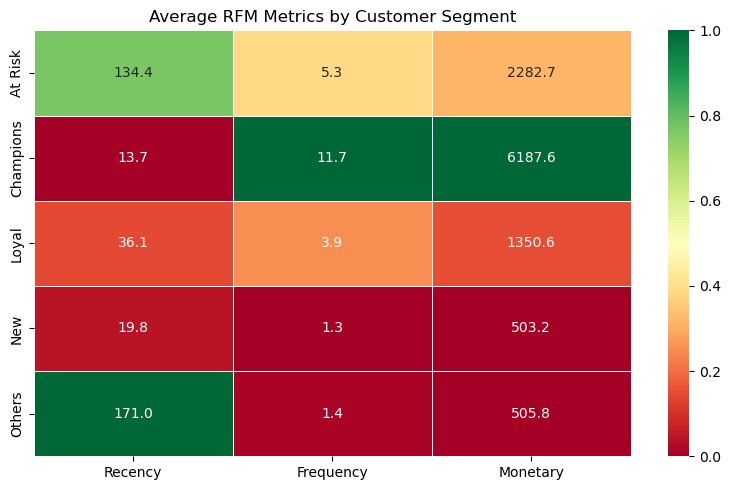

In [36]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

rfm_summary = (
    rfm
    .groupby("Segment")[["Recency", "Frequency", "Monetary"]]
    .mean()
)

scaler = MinMaxScaler()
rfm_scaled = scaler.fit_transform(rfm_summary)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    index=rfm_summary.index,
    columns=rfm_summary.columns
)

plt.figure(figsize=(8,5))

sns.heatmap(
    rfm_scaled,
    annot=rfm_summary.round(1),   # Muestra los valores originales
    fmt="",
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title("Average RFM Metrics by Customer Segment")
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()

<br>The RFM segmentation reveals five distinct customer groups with clearly differentiated purchasing behaviors.

Champions (926 customers) are the most valuable segment. They purchased very recently (average Recency of 13.7 days), place orders frequently (an average of 11.7 purchases), and generate by far the highest revenue, with an average expenditure of £6,188 per customer.

Loyal customers (973) also exhibit strong purchasing behavior, although they are less active and spend less than Champions. On average, they purchased 36 days before the reference date, placed 3.9 orders, and spent approximately £1,351.

New customers (367) have purchased recently (average Recency of 19.8 days) but have completed only 1.3 purchases on average and have relatively low total spending (£503). This suggests that they are recent acquisitions with the potential to become loyal customers.

At Risk customers (320) previously generated considerable value, averaging 5.3 purchases and £2,283 in total spending. However, they have not purchased for an average of 134 days, making them suitable targets for retention campaigns.

Finally, the largest segment, Others (1,726 customers), consists mainly of low-value and inactive customers. They purchased infrequently (an average of 1.4 orders), spent relatively little (£506), and have the highest average Recency (171 days), indicating that many of them have likely become inactive.<br>

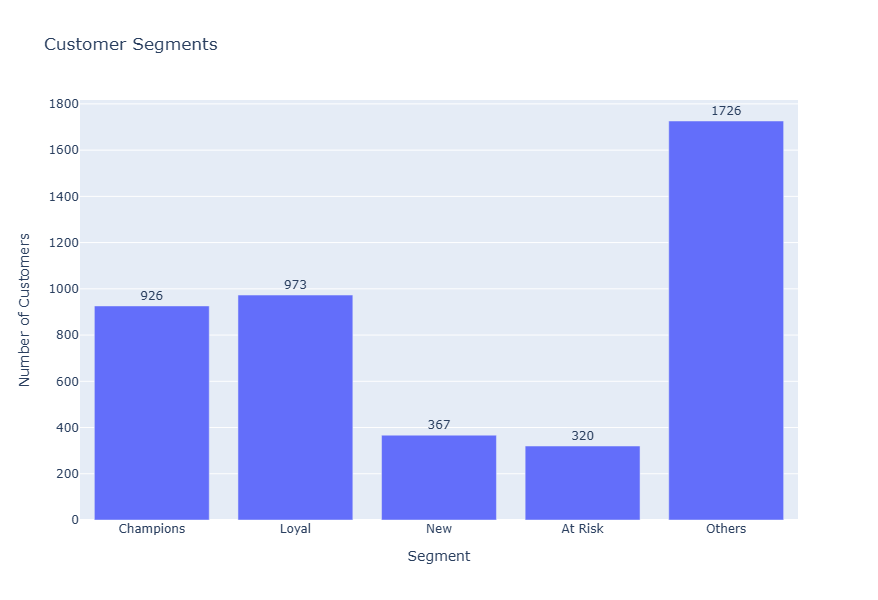

In [37]:
import plotly.express as px

segment_counts = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["Segment", "Customers"]

order = ["Champions", "Loyal", "New", "At Risk", "Others"]

segment_counts["Segment"] = pd.Categorical(
    segment_counts["Segment"],
    categories=order,
    ordered=True
)

segment_counts = segment_counts.sort_values("Segment")

fig = px.bar(
    segment_counts,
    x="Segment",
    y="Customers",
    text="Customers",
    title="Customer Segments"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    xaxis_title="Segment",
    yaxis_title="Number of Customers",
    height=600
)

fig.show()

From a business perspective, the At Risk segment deserves special attention. Although these customers have not made a purchase for a relatively long period, they previously generated a high average revenue (£2,283 per customer), significantly higher than the Loyal segment. Targeted marketing campaigns, such as personalized promotions, exclusive discounts, or loyalty incentives, could encourage these customers to return and help recover a valuable source of revenue.

Now that we know the number of customers in each segment, it would be interesting to calculate how much revenue comes from each one.

In [38]:
segment_revenue = (
    rfm.groupby("Segment")[["Monetary"]]
    .sum()
)

segment_revenue["revenue_share (%)"] = (
    segment_revenue["Monetary"]
    / segment_revenue["Monetary"].sum()
    * 100
).round(2)

segment_revenue = segment_revenue.sort_values(
    by="Monetary",
    ascending=False
)

display(
    segment_revenue.style.format({
        "Monetary": "£{:,.2f}",
        "revenue_share (%)": "{:.2f}%"
    })
)

,Monetary,revenue_share (%)
Segment,,
Champions,"£5,729,743.40",64.87%
Loyal,"£1,314,097.08",14.88%
Others,"£873,020.37",9.88%
At Risk,"£730,452.19",8.27%
New,"£184,690.23",2.09%


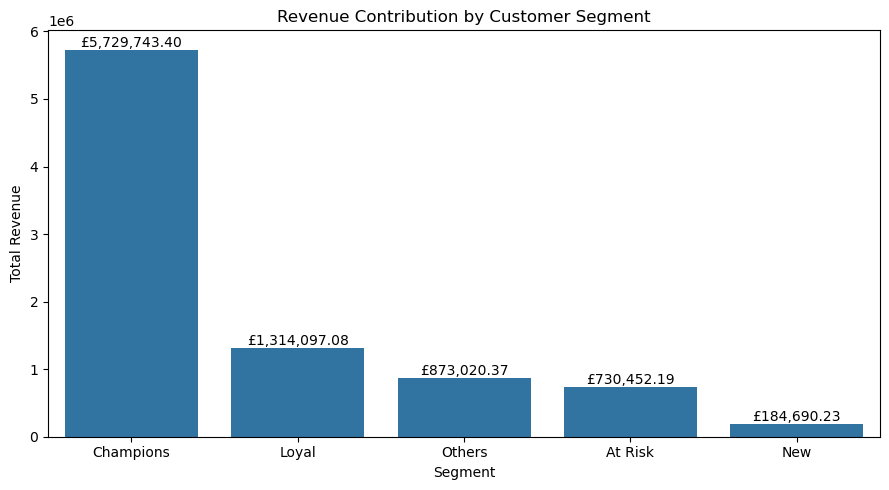

In [40]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=segment_revenue.reset_index(),
    x="Segment",
    y="Monetary"
)

# Etiquetas encima de las barras
for container in ax.containers:
    ax.bar_label(container, fmt="£{:,.2f}", fontsize=10)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

The Champions segment generates over £5.7 million in revenue, representing 64.87% of the company's total revenue. This highlights the critical importance of retaining these high-value customers through loyalty programs and personalized marketing strategies.

In [39]:
sales_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country,TotalPrice,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,Tuesday


In [41]:
sales_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country,TotalPrice,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,Tuesday


## KMEANS CLUSTERING

In this section we will automatically group customers into segments, without predefined rules, using K-means. 

K-Means was selected because it is one of the most widely used and interpretable clustering algorithms for customer segmentation. Since the objective was to group customers with similar purchasing behavior based on Recency, Frequency, and Monetary (RFM) metrics, K-Means provides an efficient way to identify homogeneous customer groups by minimizing the within-cluster variance.

Due to the fact that RFM variables are highly right-skewed, a logarithmic transformation is applied before clustering. This reduces the influence of extreme values and produces more balanced clusters.

In [42]:
from sklearn.preprocessing import StandardScaler

rfm_log = rfm.copy()

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

X = rfm_log[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()

# First, we normalize the variables
X_scaled = scaler.fit_transform(X)

<br>Having normalized the variables, we can now identify the optimal number of clusters to uncover meaningful customer groups and generate actionable business insights.

In [43]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

results = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)

    distances = np.linalg.norm(
        X_scaled - kmeans.cluster_centers_[labels],
        axis=1
    )

    density = distances.mean()

    results.append({
        'K': k,
        'Silhouette': round(silhouette, 3),
        'Density': round(density, 3)
    })

comparison_df = pd.DataFrame(results)

comparison_df['Silhouette'] = comparison_df['Silhouette'].map('{:.3f}'.format).str.rstrip('0').str.rstrip('.')
comparison_df['Density'] = comparison_df['Density'].map('{:.3f}'.format).str.rstrip('0').str.rstrip('.')

comparison_df.style.hide(axis="index")

K,Silhouette,Density
2,0.422,1.113
3,0.328,0.961
4,0.332,0.857
5,0.319,0.788
6,0.312,0.741
7,0.307,0.699
8,0.281,0.673
9,0.276,0.645
10,0.281,0.619


The silhouette analysis suggests that K=2 provides the highest cluster separation. However, a two-cluster solution is too coarse to generate meaningful customer segments for business decision-making.

Although the silhouette score decreases for larger values of K, K=4 offers a strong balance between cluster cohesion, separation, and interpretability. The density metric improves substantially compared to K=2 and K=3, while maintaining a relatively stable silhouette score.

Therefore, K=4 was selected as the optimal number of clusters, as it provides actionable customer segments without excessively compromising cluster quality.

Having selected K=4 as the optimal number of clusters, we can now train the K-Means model and assign customers to their respective segments. The resulting clusters will be analyzed to uncover behavioral patterns and support data-driven business decisions.

In [44]:
kmeans = KMeans(
        n_clusters=4,
        random_state=42,
        n_init=10
    )

rfm_log["Cluster"] = kmeans.fit_predict(X_scaled)
rfm["Cluster"] = rfm_log["Cluster"]

cluster_summary = (
    rfm
    .groupby("Cluster")
    .agg(
        customers=("Cluster","count"),
        recency=("Recency","mean"),
        frequency=("Frequency","mean"),
        monetary=("Monetary","mean")
    )
)

cluster_summary

,customers,recency,frequency,monetary
Cluster,,,,
0,949,23.139094,2.053741,565.798399
1,776,13.889175,13.581186,7422.654933
2,1397,187.566929,1.289907,302.534232
3,1190,82.659664,4.136975,1775.159700


Cluster 1 represents the company's most valuable customers, characterized by the lowest average recency (14 days), the highest purchase frequency (13.6 orders), and the highest average spending (£7,423). These customers should be the primary target of loyalty and retention strategies.

Cluster 3 consists of regular customers who purchase less frequently than the Champions but still generate substantial revenue (£1,775 on average). Maintaining their engagement could help increase their long-term value.

Cluster 0 includes relatively recent customers with low purchase frequency and spending. These customers are likely to be new or occasional buyers who could be encouraged to make repeat purchases through personalized marketing campaigns.

Finally, Cluster 2 groups inactive, low-value customers. They have the highest average recency (188 days), the lowest purchase frequency, and the lowest total spending, indicating a low level of engagement with the business.

Let's look at it visually.

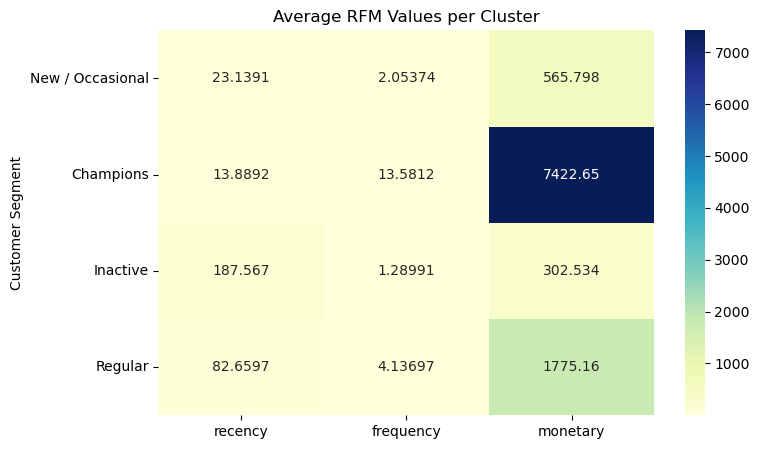

In [45]:
cluster_summary = (
    rfm
    .groupby("Cluster")
    .agg(
        recency=("Recency", "mean"),
        frequency=("Frequency", "mean"),
        monetary=("Monetary", "mean")
    )
)

cluster_summary.index = [
    "New / Occasional",
    "Champions",
    "Inactive",
    "Regular"
]

plt.figure(figsize=(8, 5))

sns.heatmap(
    cluster_summary,
    annot=True,
    fmt="g",          
    cmap="YlGnBu"
)

plt.title("Average RFM Values per Cluster")
plt.ylabel("Customer Segment")
plt.show()

If we look at the Regular segment we can see customers with moderate purchasing activity and relatively high lifetime value. Although they have made several purchases and generated substantial revenue, their average recency (83 days) is considerably higher than that of the Champions segment, suggesting that their engagement has declined over time. These customers should be considered a priority for retention campaigns, as timely personalized promotions, product recommendations, or loyalty incentives could encourage them to purchase again before they become inactive.

Now that we've defined the segments, it's time to see how much revenue each one generates.

In [48]:
segment_revenue = rfm.groupby("Cluster")[["Monetary"]].sum()

segment_revenue["revenue_share (%)"] = (
    segment_revenue["Monetary"]
    / segment_revenue["Monetary"].sum()
    * 100
).round(2)

segment_revenue = segment_revenue.sort_values(
    by="Monetary",
    ascending=False
)

display(
    segment_revenue.style.format({
        "Monetary": "£{:,.2f}",
        "revenue_share (%)": "{:.2f}%"
    })
)

,Monetary,revenue_share (%)
Cluster,,
1,"£5,759,980.23",65.22%
3,"£2,112,440.04",23.92%
0,"£536,942.68",6.08%
2,"£422,640.32",4.79%


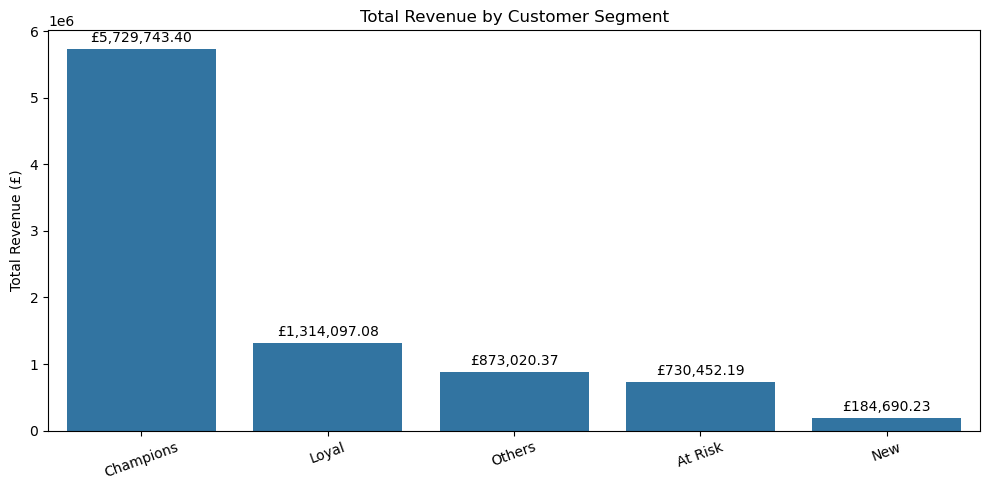

In [49]:
from matplotlib.ticker import FuncFormatter

# Revenue by segment
segment_revenue = (
    rfm.groupby("Segment", as_index=False)["Monetary"]
    .sum()
    .sort_values("Monetary", ascending=False)
)

# Plot
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=segment_revenue,
    x="Segment",
    y="Monetary"
)

# Labels on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="£{:,.2f}",
        padding=3
    )

plt.title("Total Revenue by Customer Segment")
plt.xlabel("")
plt.ylabel("Total Revenue (£)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

Cluster 1, representing the company's highest-value customers, once again dominates total revenue, generating more than £5.7 million in revenue and accounts for 65.22% of total revenue. This highlights the strategic importance of retaining and nurturing these customers through targeted loyalty and engagement initiatives.

## COMPARING RFM VS KMEANS

To validate the clustering results, the K-Means segments are going to be compared against the rule-based RFM segmentation. 

In [50]:
rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Score,Segment,Cluster
Customer ID,,,,,,,,,
12346.0,165,11,372.86,2,5,2,252,At Risk,3
12347.0,3,2,1323.32,5,2,4,524,New,0
12348.0,74,1,222.16,2,1,1,211,Others,2
12349.0,43,3,2671.14,3,3,5,335,Loyal,3
12351.0,11,1,300.93,5,1,2,512,New,0


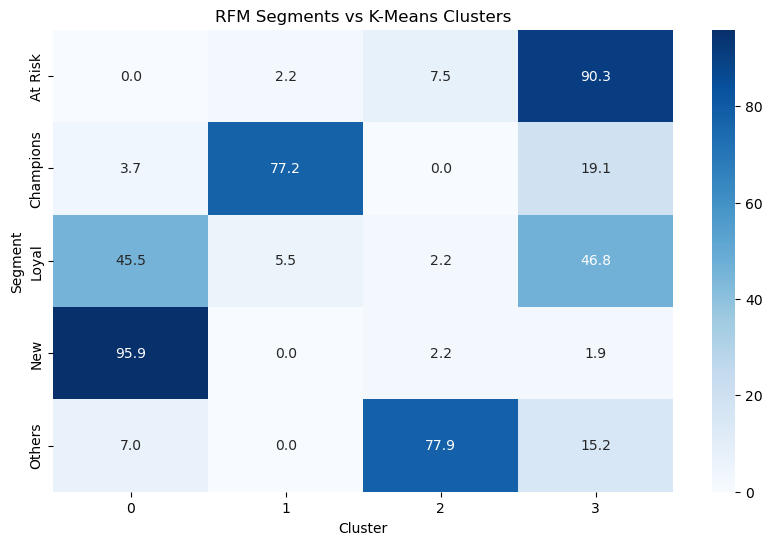

In [51]:
cross_table_pct = pd.crosstab(
    rfm['Segment'],
    rfm['Cluster'],
    normalize='index'
) * 100

plt.figure(figsize=(10,6))

sns.heatmap(
    cross_table_pct,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('RFM Segments vs K-Means Clusters')
plt.show()

The comparison shows a strong alignment between both approaches.

Customers classified as Champions are predominantly grouped into Cluster 1 (77.2%), while At Risk customers are concentrated in Cluster 3 (90.3%). Similarly, New customers are almost entirely assigned to Cluster 0 (95.9%), and Others are mainly grouped into Cluster 2 (77.9%).

The main difference appears within the Loyal segment, which is distributed across multiple clusters. This suggests that customers sharing the same RFM score may still exhibit distinct purchasing behaviors that can be captured by an unsupervised learning approach.

Overall, the strong correspondence between RFM segments and K-Means clusters provides additional validation for the clustering model while also highlighting its ability to uncover behavioral patterns that are not visible through rule-based segmentation alone.

## CUSTOMER RETENTION COHORT ANALYSIS

While RFM segmentation and K-Means clustering provide valuable insights into customer behavior at a specific point in time, they do not reveal how customer engagement evolves over time. To address this limitation, a cohort analysis was conducted by grouping customers according to the month of their first purchase and tracking their subsequent purchasing activity.

This approach allows us to evaluate customer retention patterns, identify periods of stronger or weaker engagement, and measure how effectively the business retains newly acquired customers. By analyzing customer behavior across different cohorts, we can gain a deeper understanding of long-term customer loyalty and the sustainability of revenue growth.

The resulting retention matrix highlights the percentage of customers who return to make additional purchases in subsequent months, providing actionable insights for customer retention, marketing optimization, and lifetime value improvement.

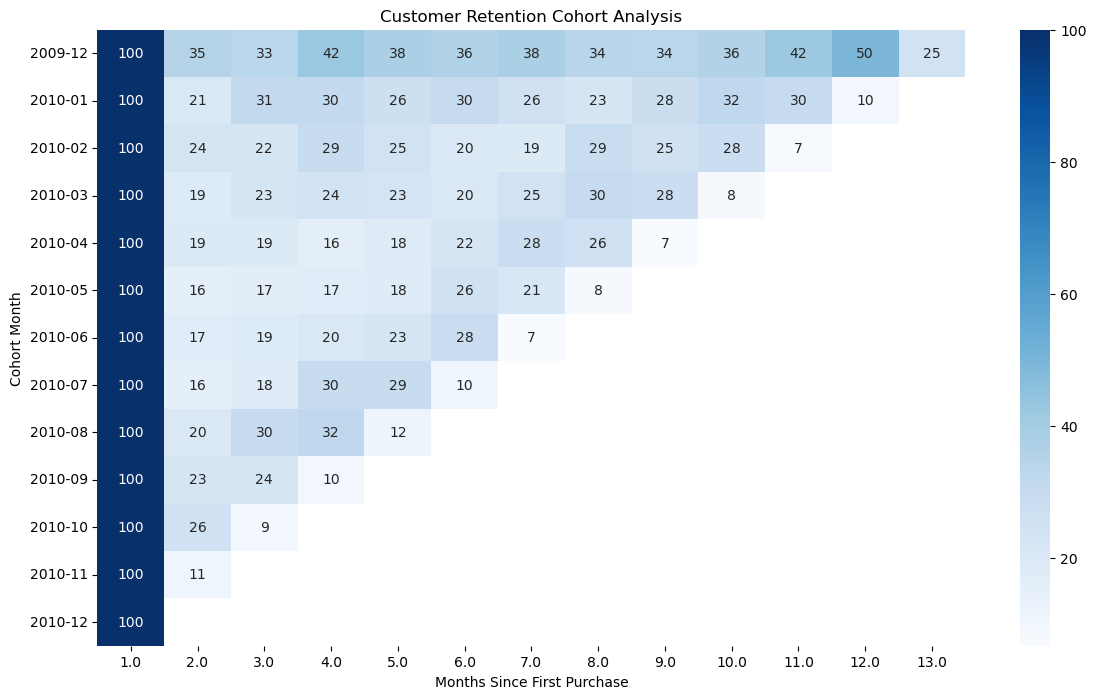

In [52]:
cohort_df = sales_df.copy()

cohort_df['InvoiceDate'] = pd.to_datetime(cohort_df['InvoiceDate'])

cohort_df['InvoiceMonth'] = cohort_df['InvoiceDate'].dt.to_period('M')

cohort_df['CohortMonth'] = cohort_df.groupby('Customer ID')['InvoiceDate']\
                                    .transform('min')\
                                    .dt.to_period('M')

def get_month_index(invoice_month, cohort_month):
    return (
        (invoice_month.year - cohort_month.year) * 12
        + (invoice_month.month - cohort_month.month)
        + 1
    )

cohort_df['CohortIndex'] = cohort_df.apply(
    lambda x: get_month_index(x['InvoiceMonth'],
                              x['CohortMonth']),
    axis=1
)

cohort_data = cohort_df.groupby(
    ['CohortMonth', 'CohortIndex']
)['Customer ID'].nunique().reset_index()

cohort_counts = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='Customer ID'
)

cohort_sizes = cohort_counts.iloc[:, 0]

retention_matrix = cohort_counts.divide(
    cohort_sizes,
    axis=0
)

retention_matrix = retention_matrix.round(3) * 100

plt.figure(figsize=(14,8))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.0f',
    cmap='Blues'
)

plt.title('Customer Retention Cohort Analysis')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')

plt.show()

The cohort analysis reveals that customer retention drops significantly after the first month, with most cohorts retaining between 15% and 35% of customers in Month 2. This suggests that a large proportion of customers make only one purchase and do not immediately return.

However, retention remains relatively stable in subsequent months, indicating the existence of a loyal customer base that continues purchasing over time. Several cohorts show retention rates above 25% even after six months, demonstrating sustained customer engagement.

The December 2009 cohort stands out as the strongest-performing group, maintaining retention levels above 30% throughout most of the observation period and reaching 50% retention after twelve months. This may indicate successful customer acquisition during the holiday season or the presence of highly engaged customers acquired during that period.

Overall, the analysis highlights both a customer retention challenge in the early stages of the customer lifecycle and an opportunity to increase long-term customer value through targeted retention strategies aimed at improving second-purchase rates.

The most critical moment in the customer lifecycle is not long-term retention, but rather securing the second purchase. Once customers return after their first transaction, retention tends to stabilize considerably across most cohorts.

## BUSINESS INSIGHTS

Based on the customer segmentation results, the company could implement different marketing strategies tailored to the characteristics of each customer segment:

**Champions**: These customers are the company's most valuable assets, as they purchase frequently, spend the most, and have bought recently. They should be rewarded through loyalty programs, exclusive discounts, early access to new products, and personalized offers to maintain their engagement and strengthen long-term relationships.

**Regular Customers**: Although these customers are not as valuable as the Champions, they have demonstrated consistent purchasing behavior. Personalized promotions, cross-selling opportunities, and retention campaigns could encourage them to make more frequent purchases and eventually move into the Champions segment.

**New or Occasional Customers**: Since these customers have made only a few purchases, the main objective should be to encourage repeat buying. Welcome discounts, personalized product recommendations, follow-up emails, and introductory loyalty incentives can help build customer loyalty and increase purchase frequency.

**Loyal Customers**: By offering personalized product recommendations, loyalty rewards, or exclusive promotions, the company can encourage these customers to increase their spending and gradually move into the Champions segment.

Overall, adopting a differentiated marketing strategy based on customer purchasing behavior allows the company to allocate its marketing resources more efficiently, improve customer retention, and maximize long-term revenue.

## EXECUTIVE DASHBOARD

The following executive dashboard consolidates the key results obtained throughout the analysis. It summarizes the main business indicators, sales trends, and customer segmentation outcomes, providing a concise overview of the insights that can support data-driven decision-making.

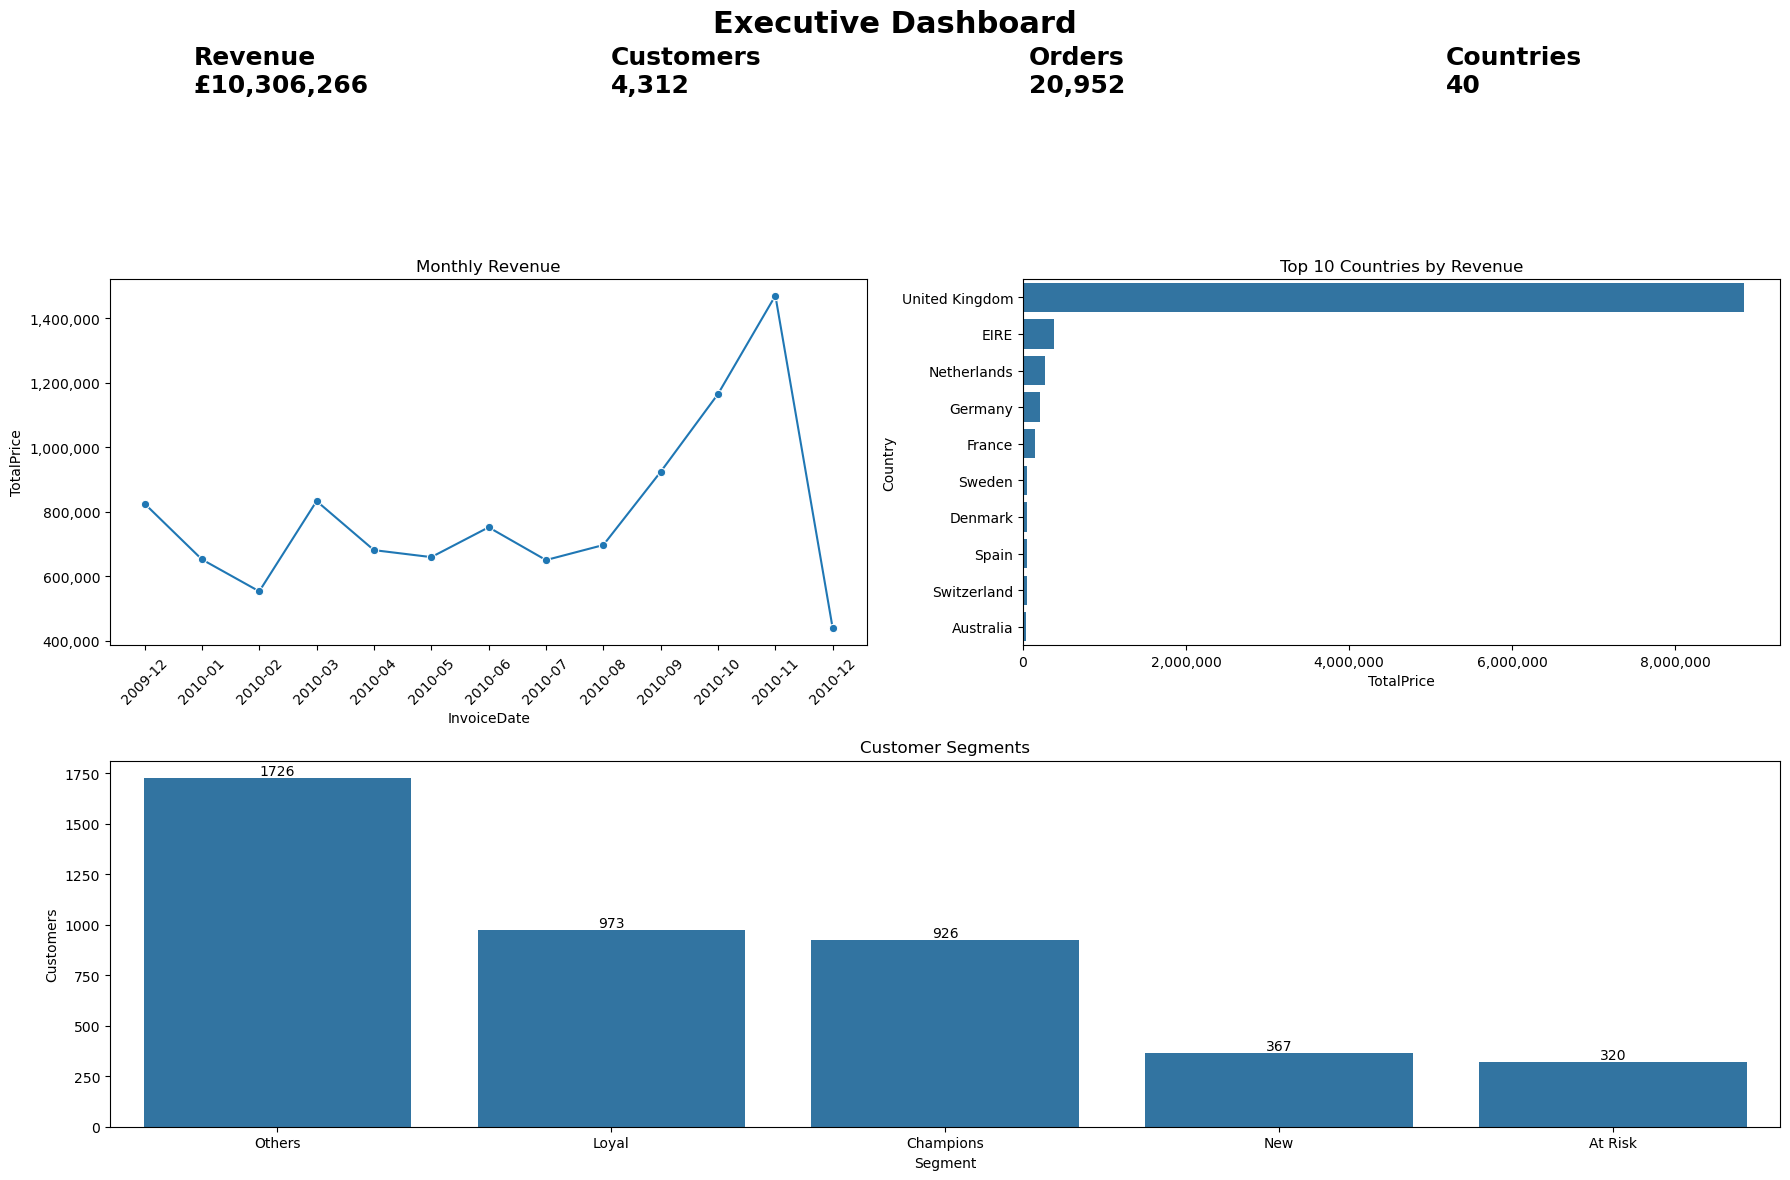

In [53]:
from matplotlib.ticker import StrMethodFormatter

# KPIs
total_revenue = sales_df["TotalPrice"].sum()
total_customers = sales_df["Customer ID"].nunique()
total_orders = sales_df["Invoice"].nunique()
total_countries = sales_df["Country"].nunique()

# Monthly revenue
monthly_sales = (
    sales_df
    .groupby(sales_df["InvoiceDate"].dt.to_period("M"))["TotalPrice"]
    .sum()
    .reset_index()
)

monthly_sales["InvoiceDate"] = monthly_sales["InvoiceDate"].astype(str)

# Revenue by country
country_sales = (
    sales_df
    .groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Customer segments
segment_counts = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["Segment", "Customers"]

# Dashboard

fig = plt.figure(figsize=(18,12))

gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[0.6,2,2]
)

# KPIs
ax0 = fig.add_subplot(gs[0,:])
ax0.axis("off")

ax0.text(
    0.05,
    0.65,
    f"Revenue\n£{total_revenue:,.0f}",
    fontsize=18,
    fontweight="bold"
)

ax0.text(
    0.30,
    0.65,
    f"Customers\n{total_customers:,}",
    fontsize=18,
    fontweight="bold"
)

ax0.text(
    0.55,
    0.65,
    f"Orders\n{total_orders:,}",
    fontsize=18,
    fontweight="bold"
)

ax0.text(
    0.80,
    0.65,
    f"Countries\n{total_countries}",
    fontsize=18,
    fontweight="bold"
)

# Monthly revenue
ax1 = fig.add_subplot(gs[1,0])

sns.lineplot(
    data=monthly_sales,
    x="InvoiceDate",
    y="TotalPrice",
    marker="o",
    ax=ax1
)

ax1.set_title("Monthly Revenue")
ax1.tick_params(axis="x", rotation=45)
ax1.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Revenue by country
ax2 = fig.add_subplot(gs[1,1])

sns.barplot(
    data=country_sales,
    y="Country",
    x="TotalPrice",
    ax=ax2
)

ax2.set_title("Top 10 Countries by Revenue")
ax2.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Customer Segments
ax3 = fig.add_subplot(gs[2,:])

sns.barplot(
    data=segment_counts,
    x="Segment",
    y="Customers",
    ax=ax3
)

ax3.set_title("Customer Segments")

for container in ax3.containers:
    ax3.bar_label(container)

plt.suptitle(
    "Executive Dashboard",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## KEY FINDINGS

- Sales increased steadily throughout 2010, with a strong peak before the Christmas season.

- More than 90% of transactions originated in the United Kingdom.
    
- Four distinct customer segments were identified using RFM analysis and K-Means clustering.

- High-value customers account for a relatively small proportion of the customer base but generate a significant share of revenue.

- Several business strategies were proposed to improve retention and customer lifetime value.

## LIMITATIONS

Although the analysis provides valuable insights into customer purchasing behavior, several limitations should be considered:

- **Incomplete customer information:** Around 20% of the transactions do not contain a customer identifier. While these records can be used for sales analysis, they cannot be included in customer segmentation.

- **Limited observation period:** The dataset covers approximately one year of transactions (December 2009 to December 2010), preventing the analysis of long-term customer behavior and trends.

- **Limited customer attributes:** Customer segmentation is based exclusively on transactional variables (Recency, Frequency, and Monetary). Additional information such as age, gender, location, or marketing interactions could lead to more comprehensive customer profiles.

- **K-Means assumptions:** K-Means assumes that clusters are approximately spherical and of similar variance. Although logarithmic transformation and feature scaling improve the results, other clustering techniques (e.g., hierarchical clustering or DBSCAN) might identify different customer structures.

## CONCLUSIONS

This project demonstrated how customer transaction data can be transformed into actionable business insights through exploratory data analysis, data preparation, and customer segmentation techniques.

After cleaning the dataset and addressing data quality issues, an exploratory analysis revealed sales trends, seasonal patterns, and customer activity throughout the period covered by the data. Monthly sales and the number of active customers showed a clear upward trend during 2010, with a noticeable increase in the months leading up to the Christmas shopping season.

Customer behavior was then analyzed using the RFM (Recency, Frequency, Monetary) framework, providing an initial segmentation based on purchasing habits. To further identify groups of customers with similar characteristics, K-Means clustering was applied after appropriate data transformation and normalization. The resulting clusters highlighted distinct customer profiles, ranging from high-value loyal customers to inactive customers who may require re-engagement strategies.

Finally, the analysis was translated into practical business recommendations, demonstrating how customer segmentation can support targeted marketing campaigns, customer retention initiatives, and more efficient allocation of marketing resources.

Overall, this project illustrates the value of combining exploratory data analysis, feature engineering, RFM analysis, and unsupervised machine learning to better understand customer behavior and support data-driven business decision-making.

## BUSINESS IMPACT

The customer segmentation developed in this project provides actionable insights that can support data-driven decision-making across marketing, sales, and customer relationship management. By understanding the different behaviors and value levels of customer groups, the company can design more effective strategies tailored to each segment.

1. Improve Customer Retention

Identifying high-value customers who show signs of reduced engagement allows the business to implement targeted retention campaigns before churn occurs. For example, customers classified as "At Risk" can receive personalized incentives, exclusive offers, or re-engagement communications designed to encourage repeat purchases. Retaining existing customers is generally more cost-effective than acquiring new ones and contributes directly to long-term profitability.

2. Personalize Marketing Campaigns

Different customer segments have distinct purchasing behaviors and preferences. Rather than applying the same marketing strategy to all customers, the company can tailor messages, promotions, and product recommendations according to each segment's characteristics. This personalized approach can improve engagement rates, increase conversion rates, and enhance the overall customer experience.

3. Increase Customer Lifetime Value (CLV)

Customer segmentation enables the identification of loyal and high-spending customers who may be receptive to premium products, cross-selling opportunities, or loyalty programs. By nurturing these valuable customer relationships and encouraging higher purchase frequency, the company can maximize the long-term revenue generated by each customer throughout their lifecycle.

4. Optimize Promotional Spending

Marketing budgets can be allocated more efficiently by focusing resources on customer groups with the highest potential return. Instead of distributing discounts broadly, promotions can be targeted toward segments that are more likely to respond positively. This reduces unnecessary marketing costs while improving campaign effectiveness and overall return on investment (ROI).

## NEXT STEPS

While this project focused on customer segmentation through RFM analysis and K-Means clustering, several opportunities remain to extend its business value and analytical depth:

1. Customer Churn Prediction

Develop a predictive model to identify customers who are likely to stop purchasing in the near future. By leveraging behavioral indicators such as purchase frequency, recency, spending patterns, and product preferences, the company could proactively target at-risk customers with retention campaigns and personalized offers.

2. Customer Lifetime Value (CLV) Forecasting

Estimate the future value of each customer rather than relying solely on historical spending. Predictive CLV models would help prioritize marketing investments, optimize customer acquisition costs, and identify high-potential customers at an early stage of their lifecycle.

3. Product Recommendation System

Build a recommendation engine based on customer purchasing behavior. Techniques such as collaborative filtering, association rules, or content-based recommendations could increase cross-selling and upselling opportunities while enhancing the customer experience through personalized product suggestions.